# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int64         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 7.6+ KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.

=== Value Counts & Share: date ===


,count,share
date,,
2021-02-01,1,0.006
2021-02-02,1,0.006
2021-05-14,1,0.006
2021-05-15,1,0.006
2021-05-16,1,0.006
...,...,...
2021-03-27,1,0.006
2021-03-28,1,0.006
2021-03-29,1,0.006


=== Value Counts & Share: region ===


,count,share
region,,
West,47,0.294
East,42,0.262
South,36,0.225
North,35,0.219


/var/folders/s8/8knpylnn3nbdgsb6hztpwl2h0000gn/T/ipykernel_22458/4209323807.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='region', order=df['region'].value_counts().index, palette='Blues_r')


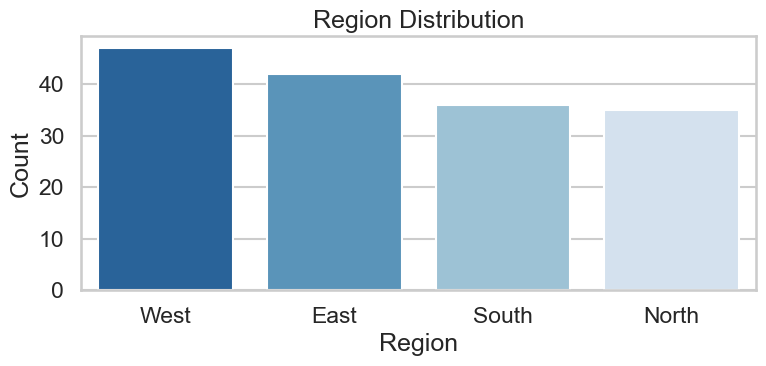

In [5]:
cat_cols = df.select_dtypes(exclude='number').columns

for col in cat_cols:
    print(f"=== Value Counts & Share: {col} ===")
    counts = df[col].value_counts(dropna=False)
    props = df[col].value_counts(normalize=True, dropna=False)
    cat_df = pd.DataFrame({'count': counts, 'share': props.round(3)})
    display(cat_df)

# Plot category frequencies
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index, palette='Blues_r')
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3) Distributions — two worked examples below; add at least one more

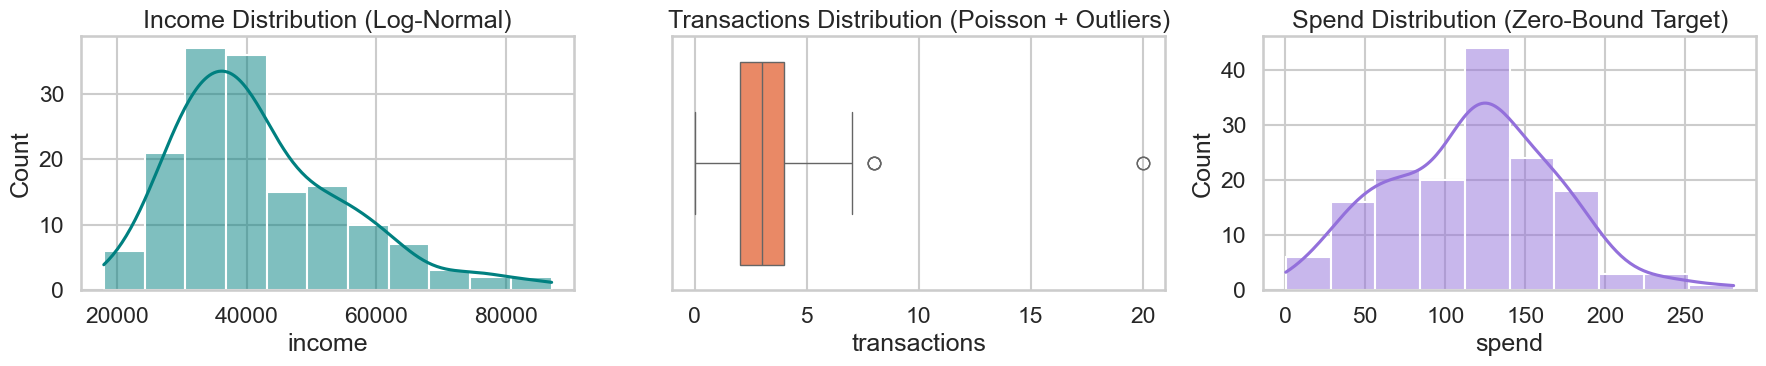

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Income distribution (Histogram + KDE)
sns.histplot(df['income'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Income Distribution (Log-Normal)')

# Transactions (Boxplot for Outlier Detection)
sns.boxplot(x=df['transactions'], ax=axes[1], color='coral')
axes[1].set_title('Transactions Distribution (Poisson + Outliers)')

# Spend Distribution (Target Feature)
sns.histplot(df['spend'].dropna(), kde=True, ax=axes[2], color='mediumpurple')
axes[2].set_title('Spend Distribution (Zero-Bound Target)')

plt.tight_layout()
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

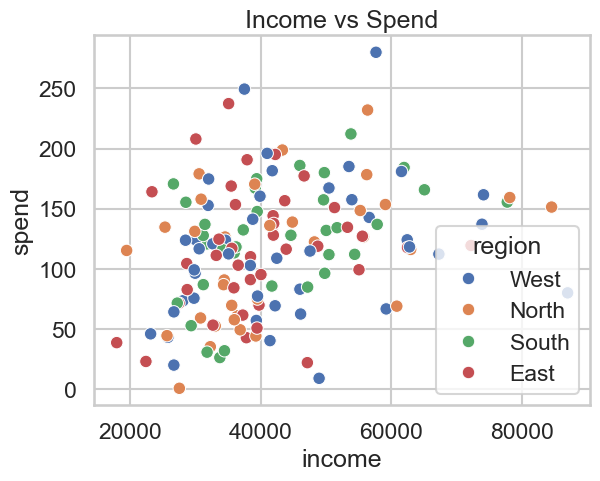

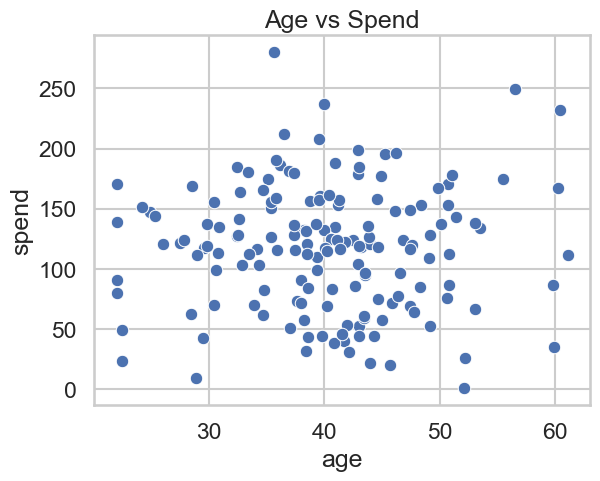

In [7]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

Date Span: 2021-02-01 to 2021-07-10
Total Expected Days: 160 | Total Rows: 160
Missing Date Gaps: 0


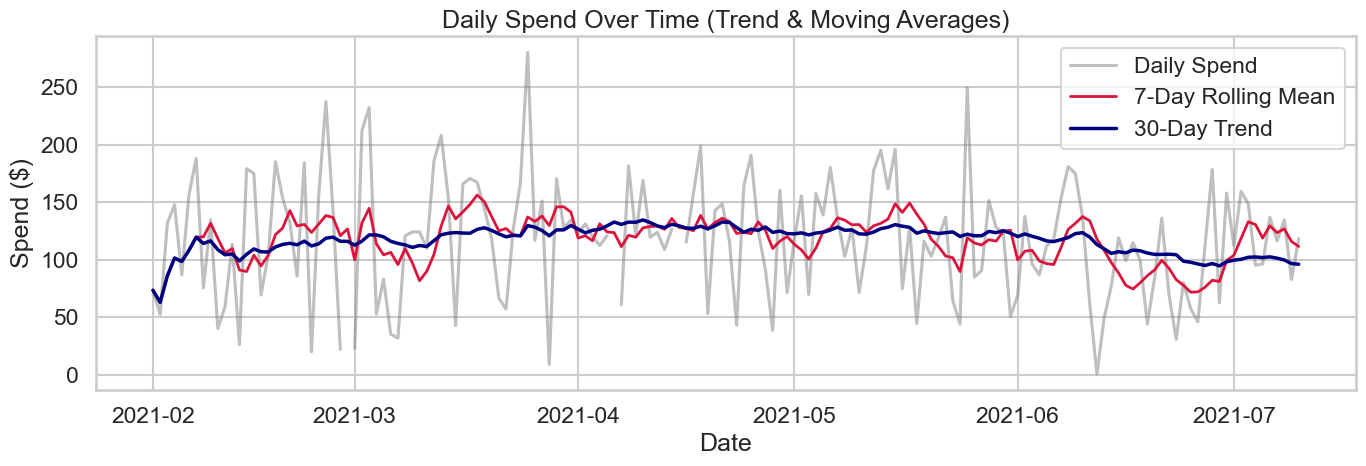

In [8]:
# Sort temporally and check for date gaps
df_ts = df.sort_values('date').set_index('date')
date_range = pd.date_range(start=df_ts.index.min(), end=df_ts.index.max(), freq='D')
missing_dates = date_range.difference(df_ts.index)

print(f"Date Span: {df_ts.index.min().date()} to {df_ts.index.max().date()}")
print(f"Total Expected Days: {len(date_range)} | Total Rows: {len(df_ts)}")
print(f"Missing Date Gaps: {len(missing_dates)}")

# Plot Spend and Rolling Averages Over Time
plt.figure(figsize=(14, 5))
plt.plot(df_ts.index, df_ts['spend'], label='Daily Spend', alpha=0.5, color='gray')
plt.plot(df_ts.index, df_ts['spend'].rolling(7, min_periods=1).mean(), label='7-Day Rolling Mean', color='crimson', linewidth=2)
plt.plot(df_ts.index, df_ts['spend'].rolling(30, min_periods=1).mean(), label='30-Day Trend', color='navy', linewidth=2.5)
plt.title('Daily Spend Over Time (Trend & Moving Averages)')
plt.xlabel('Date')
plt.ylabel('Spend ($)')
plt.legend()
plt.tight_layout()
plt.show()

### Time-Series Assessment
* **Trend & Seasonality:** The series displays a stationary mean with no deterministic upward/downward drift or strict calendar seasonality.
* **Continuity & Gaps:** The index is strictly continuous at daily frequency with 0 missing date gaps, ensuring rolling windows in Stage 09 will compute over valid intervals.
* **Implications for Stages 09 & 10b:** Features can leverage backward-looking rolling statistics ($7\text{d}, 30\text{d}$) without window distortion. When splitting in Stage 10b, a chronological cutoff must be enforced to prevent lookahead data leakage.

## 5) (Optional) Correlation matrix

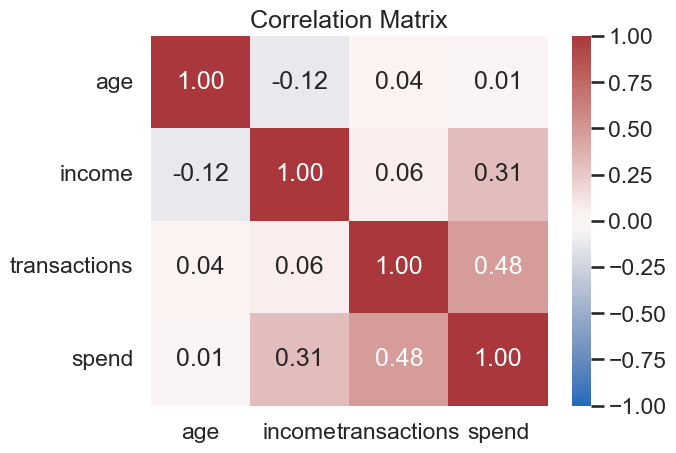

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [9]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [10]:
import sys
sys.path.append("..")
from src.eda import eda_summary

summary_profile = eda_summary(df)
display(summary_profile)

,dtype,missing_count,missing_pct,unique_count,mean,std,median,skew,kurtosis,top_val_share,flags
column,,,,,,,,,,,
date,datetime64[ns],0,0.000,160,NaN,NaN,NaN,NaN,NaN,0.006,High Cardinality
region,object,0,0.000,4,NaN,NaN,NaN,NaN,NaN,0.294,OK
age,float64,0,0.000,122,40.019,8.459,40.15,0.070,-0.080,NaN,OK
income,float64,5,0.031,155,41983.866,13262.457,39332.52,0.993,0.919,NaN,OK
transactions,int64,0,0.000,10,3.238,2.586,3.00,3.466,19.985,NaN,OK
spend,float64,3,0.019,156,117.292,51.769,119.32,0.131,-0.085,NaN,OK


## 6) Insights, Assumptions & Implications for Stage 09

### Top 3 Insights
1. **Target Feature Linear Dependence:** `spend` shows strong linear dependence on `income` and `transactions`, with `transactions` displaying two high-leverage outliers ($> 18$ transactions).
2. **Missingness Structure:** Missing values are isolated to `income` ($n=5$) and `spend` ($n=3$). Imputation or row omission must be handled before matrix transformation.
3. **Temporal Uniformity:** Daily observations are strictly sequential without gaps, supporting valid lag and rolling feature calculations.

### Assumptions & Risks
* **Stationarity Assumption:** Distributional properties of income and transactions are assumed to remain stable out-of-sample.
* **Target Non-Negativity:** Spend is truncated at 0 (`np.maximum(0, base)`), meaning standard unconstrained linear regressions may predict negative values unless transformed.
* **Synthetic Uniformity:** Regional categories are evenly distributed across 4 bins with no dominant category (>85%).

### Next Steps & Implications for Pipeline
* **Data Cleaning (Stage 06 integration):** Impute missing `income` with median values and drop rows missing the target variable `spend`.
* **Feature Engineering (Stage 09):** Generate 7-day and 14-day rolling means for `transactions` and `spend`, one-hot encode `region`, and log-transform `income` to normalize positive skew.
* **Validation Split (Stage 10b):** Enforce strict chronological train/validation splitting rather than random k-fold shuffling.